In [1]:
# Cell 1 — Verify the Colab Python environment
# IMPORTANT: This notebook does not reinstall NumPy/sklearn/PyTorch in-place.
# Colab already provides the required packages. Reinstalling NumPy while the
# runtime is active can leave mixed binary files and cause import errors.

import numpy as np
import sklearn
import torch
import torchvision
from PIL import Image

print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Pillow:", Image.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: No CUDA GPU detected. In Colab, enable a GPU under Runtime > Change runtime type.")


NumPy: 2.1.3
scikit-learn: 1.6.1
PyTorch: 2.11.0+cu130
Torchvision: 0.26.0+cu130
Pillow: 11.3.0
CUDA available: True
GPU: Tesla T4


In [2]:
# Cell 2 — Mount Google Drive and define baseline-specific project paths

from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = "/content/drive/MyDrive/NNDL_Deepfake_Project"
DATA_DIR = f"{PROJECT_DIR}/dataset"

# Separate folders so the CNN baseline never overwrites EfficientNet outputs.
CHECKPOINT_DIR = f"{PROJECT_DIR}/checkpoints_cnn_baseline"
RESULTS_DIR = f"{PROJECT_DIR}/results_cnn_baseline"

import os
for d in [PROJECT_DIR, DATA_DIR, CHECKPOINT_DIR, RESULTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("Dataset folder:", DATA_DIR)
print("CNN checkpoint folder:", CHECKPOINT_DIR)
print("CNN results folder:", RESULTS_DIR)

print("\nFiles currently in dataset folder:")
for name in os.listdir(DATA_DIR):
    print(" -", name)


Mounted at /content/drive
Dataset folder: /content/drive/MyDrive/NNDL_Deepfake_Project/dataset
CNN checkpoint folder: /content/drive/MyDrive/NNDL_Deepfake_Project/checkpoints_cnn_baseline
CNN results folder: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline

Files currently in dataset folder:
 - Real vs Fake Faces.zip


In [3]:
# Cell 3 — Extract the ZIP into the Colab runtime

import glob, zipfile, os

zip_files = glob.glob(os.path.join(DATA_DIR, "*.zip"))
if not zip_files:
    raise FileNotFoundError(
        f"No .zip file found in {DATA_DIR}. Put 'Real vs Fake Faces.zip' inside the dataset folder."
    )

preferred = [p for p in zip_files if "Real vs Fake Faces".lower() in os.path.basename(p).lower()]
ZIP_PATH = preferred[0] if preferred else zip_files[0]

EXTRACT_DIR = "/content/real_fake_faces"

if os.path.exists(EXTRACT_DIR) and os.path.isdir(EXTRACT_DIR):
    print("Existing extraction found:", EXTRACT_DIR)
else:
    print("Extracting:", ZIP_PATH)
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        bad = z.testzip()
        if bad is not None:
            raise RuntimeError(f"ZIP integrity check failed at member: {bad}")
        z.extractall(EXTRACT_DIR)
    print("Extraction complete.")

print("Runtime dataset location:", EXTRACT_DIR)


Extracting: /content/drive/MyDrive/NNDL_Deepfake_Project/dataset/Real vs Fake Faces.zip
Extraction complete.
Runtime dataset location: /content/real_fake_faces


In [4]:
# Cell 4 — Inspect the extracted dataset structure

from pathlib import Path

def print_tree(root, max_depth=4):
    root = Path(root)
    for path in sorted(root.rglob("*")):
        rel = path.relative_to(root)
        if len(rel.parts) <= max_depth:
            indent = "  " * (len(rel.parts) - 1)
            prefix = "📁" if path.is_dir() else "📄"
            print(f"{indent}{prefix} {path.name}")

print_tree(EXTRACT_DIR, max_depth=4)


📁 Real vs Fake Faces
  📁 6040
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 7030
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 7525
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real
  📁 8020
    📁 test
      📁 fake
      📁 real
    📁 train
      📁 fake
      📁 real
    📁 valid
      📁 fake
      📁 real


In [5]:
# Cell 5 — Select ONLY the exact dataset-provided 8020 split

from pathlib import Path

EXPECTED_CLASSES = {"fake", "real"}

def has_exact_class_folders(path):
    path = Path(path)
    if not path.is_dir():
        return False
    class_dirs = {p.name.lower() for p in path.iterdir() if p.is_dir()}
    return class_dirs == EXPECTED_CLASSES

def find_8020_split(root):
    root = Path(root)
    exact = [p for p in [root] + list(root.rglob("*"))
             if p.is_dir() and p.name.lower() == "8020"]

    for p in exact:
        children = {x.name.lower(): x for x in p.iterdir() if x.is_dir()}
        required = {"train", "valid", "test"}
        if required.issubset(children) and all(
            has_exact_class_folders(children[s]) for s in required
        ):
            return p

    raise RuntimeError(
        "Could not find the exact folder named '8020' containing "
        "train/fake+real, valid/fake+real, and test/fake+real."
    )

split_root = find_8020_split(EXTRACT_DIR)
TRAIN_DIR = split_root / "train"
VAL_DIR = split_root / "valid"
TEST_DIR = split_root / "test"

print("SELECTED SPLIT: PROVIDED 8020 ONLY")
print("Split root:", split_root)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

for split_name, split_dir in [
    ("train", TRAIN_DIR), ("valid", VAL_DIR), ("test", TEST_DIR)
]:
    assert split_dir.is_dir(), f"Missing {split_name}: {split_dir}"
    assert has_exact_class_folders(split_dir), (
        f"{split_name} must contain exactly fake and real folders"
    )


SELECTED SPLIT: PROVIDED 8020 ONLY
Split root: /content/real_fake_faces/Real vs Fake Faces/8020
Train: /content/real_fake_faces/Real vs Fake Faces/8020/train
Validation: /content/real_fake_faces/Real vs Fake Faces/8020/valid
Test: /content/real_fake_faces/Real vs Fake Faces/8020/test


## Data integrity checks

The next cell checks the exact same dataset used by the EfficientNet experiment:
1. corrupted/unreadable images;
2. exact duplicate image bytes;
3. duplicates crossing train/validation/test boundaries;
4. duplicates appearing under both fake and real inside one split.

The notebook refuses to train if cross-split exact duplicates or fake/real exact duplicates are found.


In [6]:
# Cell 6 — Corrupted-image and exact-duplicate checks

from PIL import Image, ImageFile
from collections import defaultdict
import hashlib, json, time

ImageFile.LOAD_TRUNCATED_IMAGES = False
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

def image_files(folder):
    return sorted(
        p for p in Path(folder).rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)
    return h.hexdigest()

start = time.time()
corrupt = []
hash_to_paths = defaultdict(list)
split_counts = {}

for split_name, split_dir in [
    ("train", TRAIN_DIR), ("valid", VAL_DIR), ("test", TEST_DIR)
]:
    counts = {}
    for class_name in ["fake", "real"]:
        paths = image_files(split_dir / class_name)
        counts[class_name] = len(paths)

        for p in paths:
            try:
                with Image.open(p) as im:
                    im.verify()
                with Image.open(p) as im:
                    im.convert("RGB").load()
            except Exception as e:
                corrupt.append({"path": str(p), "error": repr(e)})

            hash_to_paths[sha256_file(p)].append(str(p))

    split_counts[split_name] = counts

cross_split_duplicates = []
same_split_duplicates = []
same_split_cross_class_duplicates = []

for digest, paths in hash_to_paths.items():
    if len(paths) > 1:
        split_names = {Path(p).parts[-3].lower() for p in paths}
        class_names = {Path(p).parts[-2].lower() for p in paths}
        item = {"sha256": digest, "paths": paths}

        if len(split_names) > 1:
            cross_split_duplicates.append(item)
        else:
            same_split_duplicates.append(item)
            if len(class_names) > 1:
                same_split_cross_class_duplicates.append(item)

print("Image counts:", json.dumps(split_counts, indent=2))
print("Corrupted/unreadable images:", len(corrupt))
print("Exact duplicate groups within a split:", len(same_split_duplicates))
print("Exact duplicate groups crossing train/valid/test:", len(cross_split_duplicates))
print(
    "Exact duplicate groups crossing fake/real inside one split:",
    len(same_split_cross_class_duplicates)
)
print(f"Integrity scan time: {time.time() - start:.1f}s")

if corrupt:
    raise RuntimeError("Corrupted images were found. Fix the dataset before training.")

if cross_split_duplicates:
    raise RuntimeError(
        "Exact duplicate image content exists across train/valid/test. "
        "Refusing to train until this is reviewed."
    )

if same_split_cross_class_duplicates:
    raise RuntimeError(
        "The same exact image bytes appear under both fake and real. "
        "Refusing to train until this is reviewed."
    )

with open(os.path.join(RESULTS_DIR, "dataset_integrity_report.json"), "w") as f:
    json.dump({
        "split_counts": split_counts,
        "corrupt": corrupt,
        "same_split_duplicate_groups": same_split_duplicates,
        "same_split_cross_class_duplicate_groups": same_split_cross_class_duplicates,
        "cross_split_duplicate_groups": cross_split_duplicates,
    }, f, indent=2)

print("\nIntegrity checks passed.")
print("Report:", os.path.join(RESULTS_DIR, "dataset_integrity_report.json"))


Image counts: {
  "train": {
    "fake": 4000,
    "real": 4000
  },
  "valid": {
    "fake": 500,
    "real": 500
  },
  "test": {
    "fake": 500,
    "real": 500
  }
}
Corrupted/unreadable images: 0
Exact duplicate groups within a split: 0
Exact duplicate groups crossing train/valid/test: 0
Exact duplicate groups crossing fake/real inside one split: 0
Integrity scan time: 10.7s

Integrity checks passed.
Report: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/dataset_integrity_report.json


In [7]:
# Cell 7 — Reproducibility, device, and CNN training configuration

import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 32
NUM_WORKERS = 2
IMAGE_SIZE = 224

# Custom CNN baseline: one training stage, from scratch.
MAX_EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print({
    "batch_size": BATCH_SIZE,
    "image_size": IMAGE_SIZE,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "model": "Custom CNN trained from scratch",
})


Device: cuda
GPU: Tesla T4
{'batch_size': 32, 'image_size': 224, 'max_epochs': 15, 'early_stopping_patience': 3, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'model': 'Custom CNN trained from scratch'}


In [8]:
# Cell 8 — Image preprocessing, ImageFolder mapping, and DataLoaders

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Keep preprocessing aligned with the EfficientNet experiment.
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(
        brightness=0.15, contrast=0.15, saturation=0.10
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(str(TRAIN_DIR), transform=train_transform)
val_dataset = datasets.ImageFolder(str(VAL_DIR), transform=eval_transform)
test_dataset = datasets.ImageFolder(str(TEST_DIR), transform=eval_transform)

EXPECTED_CLASS_TO_IDX = {"fake": 0, "real": 1}

for split_name, ds in [
    ("train", train_dataset),
    ("valid", val_dataset),
    ("test", test_dataset)
]:
    print(f"{split_name} ImageFolder class_to_idx:", ds.class_to_idx)
    assert ds.class_to_idx == EXPECTED_CLASS_TO_IDX

FAKE_IDX = 0
REAL_IDX = 1

# Model convention:
# ImageFolder raw labels: fake=0, real=1
# BCE target:             FAKE=1, REAL=0
print("RAW ImageFolder mapping: fake=0, real=1")
print("MODEL binary target:      FAKE=1, REAL=0")

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Valid:", len(val_dataset))
print("Test :", len(test_dataset))

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
    generator=loader_generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    worker_init_fn=seed_worker,
)


train ImageFolder class_to_idx: {'fake': 0, 'real': 1}
valid ImageFolder class_to_idx: {'fake': 0, 'real': 1}
test ImageFolder class_to_idx: {'fake': 0, 'real': 1}
RAW ImageFolder mapping: fake=0, real=1
MODEL binary target:      FAKE=1, REAL=0

Dataset sizes:
Train: 8000
Valid: 1000
Test : 1000


In [9]:
# Cell 9 — HARD LABEL VERIFICATION

from collections import Counter

def verify_dataset_labels(split_name, dataset, split_dir):
    split_dir = Path(split_dir)

    print(f"\n===== {split_name.upper()} LABEL VERIFICATION =====")
    print("ImageFolder class_to_idx:", dataset.class_to_idx)
    assert dataset.class_to_idx == {"fake": 0, "real": 1}

    manual_counts = {}
    raw_counts = Counter(label for _, label in dataset.samples)

    for class_name, expected_raw_idx in [("fake", 0), ("real", 1)]:
        files = image_files(split_dir / class_name)
        manual_counts[class_name] = len(files)

        assert raw_counts[expected_raw_idx] == len(files)

        shown = 0
        for path, raw_idx in dataset.samples:
            if Path(path).parent.name.lower() == class_name and shown < 3:
                model_target = 1 if raw_idx == FAKE_IDX else 0
                print(
                    f"{Path(path).name[:55]:55s} | "
                    f"folder={class_name.upper():4s} | "
                    f"ImageFolder raw={raw_idx} | "
                    f"model target={model_target}"
                )
                assert raw_idx == expected_raw_idx
                assert model_target == (1 if class_name == "fake" else 0)
                shown += 1

    print("Folder counts:", manual_counts)
    print("ImageFolder raw-label counts:", dict(raw_counts))
    return manual_counts

counts_train = verify_dataset_labels("train", train_dataset, TRAIN_DIR)
counts_valid = verify_dataset_labels("valid", val_dataset, VAL_DIR)
counts_test = verify_dataset_labels("test", test_dataset, TEST_DIR)

print(
    "\nLABEL CHECK PASSED: fake -> target 1 (FAKE), "
    "real -> target 0 (REAL)."
)



===== TRAIN LABEL VERIFICATION =====
ImageFolder class_to_idx: {'fake': 0, 'real': 1}
002KDWZBHU.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
009X14ED19.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
00GYML2PNL.jpg                                          | folder=FAKE | ImageFolder raw=0 | model target=1
00000.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
00003.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
00009.jpg                                               | folder=REAL | ImageFolder raw=1 | model target=0
Folder counts: {'fake': 4000, 'real': 4000}
ImageFolder raw-label counts: {0: 4000, 1: 4000}

===== VALID LABEL VERIFICATION =====
ImageFolder class_to_idx: {'fake': 0, 'real': 1}
A9TZ2WUWIW.jpg                                          | folder=FAKE | ImageFolder raw=0 |

In [10]:
# Cell 10 — Build the custom CNN baseline from scratch

import torch.nn as nn

class DeepfakeCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # 224 -> 112
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 112 -> 56
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 56 -> 28
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 28 -> 14
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # 14 -> 7
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=0.4),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

model = DeepfakeCNN().to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("Training mode: from scratch — no pretrained weights.")


DeepfakeCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, 

In [11]:
# Cell 11 — Training utilities, FAKE-positive metrics, checkpoints, and RNG state

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
import math, json, time

criterion = nn.BCEWithLogitsLoss()
use_amp = torch.cuda.is_available()
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

def empty_history():
    return {
        "epoch": [],
        "train_loss": [], "val_loss": [],
        "train_accuracy": [], "val_accuracy": [],
        "train_precision": [], "val_precision": [],
        "train_recall": [], "val_recall": [],
        "train_f1": [], "val_f1": [],
        "train_roc_auc": [], "val_roc_auc": [],
        "lr": [],
    }

def fake_targets_from_imagefolder_labels(raw_labels):
    return (raw_labels == FAKE_IDX).float().unsqueeze(1)

def run_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss = 0.0
    all_labels = []
    all_probs = []

    for images, raw_labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        fake_labels = fake_targets_from_imagefolder_labels(raw_labels).to(DEVICE)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16 if DEVICE.type == "cuda" else torch.bfloat16,
                enabled=use_amp,
            ):
                logits = model(images)
                loss = criterion(logits, fake_labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * images.size(0)

        fake_probs = (
            torch.sigmoid(logits)
            .detach()
            .float()
            .cpu()
            .numpy()
            .ravel()
        )

        all_probs.extend(fake_probs.tolist())
        all_labels.extend(
            fake_labels.detach()
            .cpu()
            .numpy()
            .ravel()
            .astype(int)
            .tolist()
        )

    labels = np.asarray(all_labels)
    probs = np.asarray(all_probs)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "loss": running_loss / len(loader.dataset),
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "roc_auc": (
            roc_auc_score(labels, probs)
            if len(np.unique(labels)) == 2
            else float("nan")
        ),
    }

    return metrics, labels, probs

def rng_state():
    return {
        "python": random.getstate(),
        "numpy": np.random.get_state(),
        "torch": torch.get_rng_state(),
        "cuda": (
            torch.cuda.get_rng_state_all()
            if torch.cuda.is_available()
            else None
        ),
        "loader_generator": loader_generator.get_state(),
    }

def restore_rng_state(state):
    if not state:
        return

    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    torch.set_rng_state(state["torch"].cpu())

    if torch.cuda.is_available() and state.get("cuda") is not None:
        torch.cuda.set_rng_state_all([s.cpu() for s in state["cuda"]])

    if state.get("loader_generator") is not None:
        loader_generator.set_state(state["loader_generator"].cpu())

def save_checkpoint(path, model, optimizer, scheduler, epoch, history, best_val_loss, no_improve):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "scaler_state_dict": scaler.state_dict() if scaler else None,
        "history": history,
        "best_val_loss": best_val_loss,
        "no_improve": no_improve,
        "class_to_idx": train_dataset.class_to_idx,
        "architecture": "DeepfakeCNN_custom_baseline",
        "config": {
            "image_size": IMAGE_SIZE,
            "batch_size": BATCH_SIZE,
            "seed": SEED,
            "max_epochs": MAX_EPOCHS,
            "early_stopping_patience": EARLY_STOPPING_PATIENCE,
            "target_convention": "FAKE=1, REAL=0",
        },
        "rng_state": rng_state(),
    }, path)

def append_history(history, epoch, train_metrics, val_metrics, lr):
    history["epoch"].append(epoch)

    for key in [
        "loss", "accuracy", "precision",
        "recall", "f1", "roc_auc"
    ]:
        history[f"train_{key}"].append(float(train_metrics[key]))
        history[f"val_{key}"].append(float(val_metrics[key]))

    history["lr"].append(float(lr))


In [12]:
# Cell 12 — Train the CNN baseline with early stopping

BEST_PATH = os.path.join(
    CHECKPOINT_DIR, "cnn_baseline_best.pth"
)
LATEST_PATH = os.path.join(
    CHECKPOINT_DIR, "cnn_baseline_latest.pth"
)

history = empty_history()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=1,
)

best_val_loss = math.inf
no_improve = 0

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()

    train_metrics, _, _ = run_epoch(
        model, train_loader, optimizer
    )
    val_metrics, _, _ = run_epoch(
        model, val_loader
    )

    scheduler.step(val_metrics["loss"])

    append_history(
        history,
        epoch,
        train_metrics,
        val_metrics,
        optimizer.param_groups[0]["lr"],
    )

    improved = val_metrics["loss"] < best_val_loss

    if improved:
        best_val_loss = val_metrics["loss"]
        no_improve = 0

        save_checkpoint(
            BEST_PATH,
            model,
            optimizer,
            scheduler,
            epoch,
            history,
            best_val_loss,
            no_improve,
        )

        marker = " <-- BEST CNN"
    else:
        no_improve += 1
        marker = f" | no val-loss improvement={no_improve}"

    # Save latest after every epoch.
    save_checkpoint(
        LATEST_PATH,
        model,
        optimizer,
        scheduler,
        epoch,
        history,
        best_val_loss,
        no_improve,
    )

    print(
        f"Epoch {epoch}/{MAX_EPOCHS} | "
        f"train loss={train_metrics['loss']:.4f} | "
        f"val loss={val_metrics['loss']:.4f} | "
        f"val acc={val_metrics['accuracy']:.4f} | "
        f"val F1={val_metrics['f1']:.4f} | "
        f"{time.time() - start:.1f}s{marker}"
    )

    if no_improve >= EARLY_STOPPING_PATIENCE:
        print(
            f"\nEarly stopping: validation loss did not improve "
            f"for {EARLY_STOPPING_PATIENCE} consecutive epochs."
        )
        break

with open(
    os.path.join(RESULTS_DIR, "training_history.json"), "w"
) as f:
    json.dump(history, f, indent=2)

print("\nCNN baseline training complete.")
print("Epochs actually run:", len(history["epoch"]))
print("Best validation loss:", best_val_loss)
print("Best checkpoint:", BEST_PATH)
print("Latest checkpoint:", LATEST_PATH)


Epoch 1/15 | train loss=0.6909 | val loss=0.7290 | val acc=0.5170 | val F1=0.2069 | 52.7s <-- BEST CNN
Epoch 2/15 | train loss=0.6756 | val loss=0.6683 | val acc=0.5970 | val F1=0.6293 | 48.7s <-- BEST CNN
Epoch 3/15 | train loss=0.6598 | val loss=0.7356 | val acc=0.5350 | val F1=0.1856 | 52.3s | no val-loss improvement=1
Epoch 4/15 | train loss=0.6451 | val loss=0.6807 | val acc=0.5670 | val F1=0.2936 | 49.0s | no val-loss improvement=2
Epoch 5/15 | train loss=0.6154 | val loss=0.6198 | val acc=0.6640 | val F1=0.5990 | 52.8s <-- BEST CNN
Epoch 6/15 | train loss=0.6065 | val loss=0.5888 | val acc=0.6780 | val F1=0.6761 | 51.0s <-- BEST CNN
Epoch 7/15 | train loss=0.5854 | val loss=0.5897 | val acc=0.6720 | val F1=0.6230 | 50.7s | no val-loss improvement=1
Epoch 8/15 | train loss=0.5786 | val loss=0.5733 | val acc=0.6950 | val F1=0.7163 | 49.6s <-- BEST CNN
Epoch 9/15 | train loss=0.5672 | val loss=0.6491 | val acc=0.6380 | val F1=0.7194 | 51.9s | no val-loss improvement=1
Epoch 10/15 |

In [13]:
# Cell 13 — Load the BEST CNN checkpoint before evaluation

best_ckpt = torch.load(
    BEST_PATH,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(best_ckpt["model_state_dict"])
model.eval()

print("Loaded best CNN checkpoint:")
print("  epoch:", best_ckpt["epoch"])
print("  best validation loss:", best_ckpt["best_val_loss"])


Loaded best CNN checkpoint:
  epoch: 8
  best validation loss: 0.5732582492828369


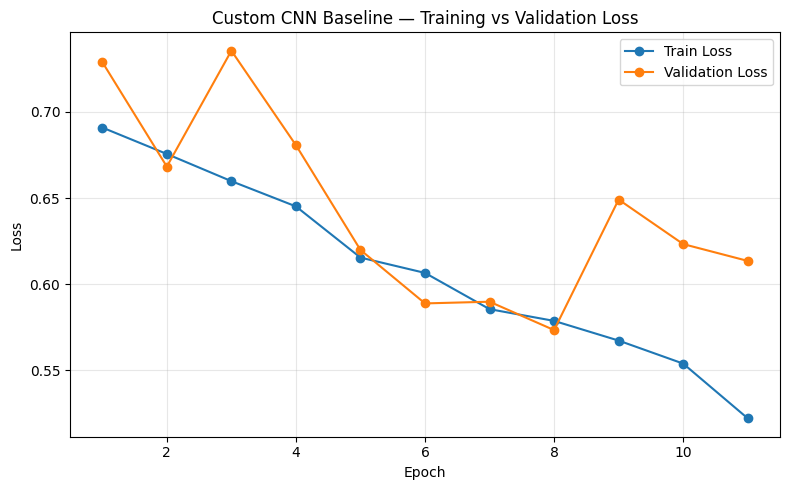

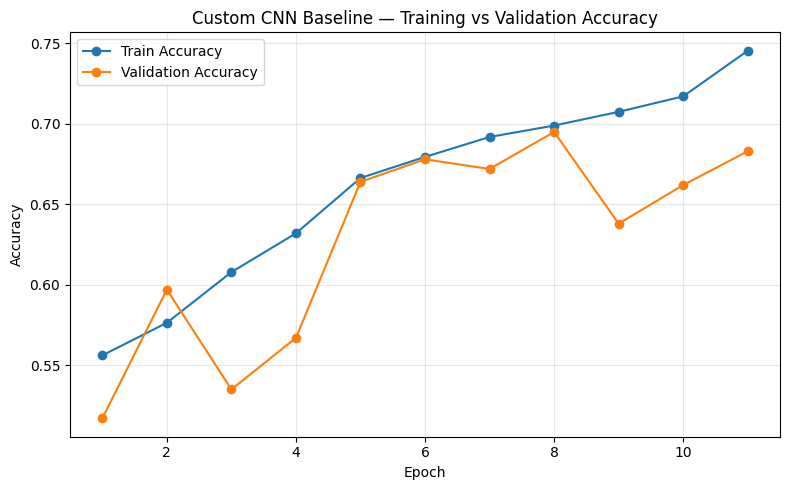

Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/cnn_baseline_loss_curve.png
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/cnn_baseline_accuracy_curve.png


In [14]:
# Cell 14 — Plot training and validation curves

import matplotlib.pyplot as plt

epochs = history["epoch"]

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], marker="o", label="Train Loss")
plt.plot(epochs, history["val_loss"], marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Custom CNN Baseline — Training vs Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

loss_path = os.path.join(RESULTS_DIR, "cnn_baseline_loss_curve.png")
plt.savefig(loss_path, dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    epochs,
    history["train_accuracy"],
    marker="o",
    label="Train Accuracy",
)
plt.plot(
    epochs,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Custom CNN Baseline — Training vs Validation Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

acc_path = os.path.join(
    RESULTS_DIR, "cnn_baseline_accuracy_curve.png"
)
plt.savefig(acc_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", loss_path)
print("Saved:", acc_path)


HELD-OUT TEST RESULTS — CUSTOM CNN BASELINE
------------------------------------------------
loss      : 0.5473
accuracy  : 0.7230
precision : 0.6988
recall    : 0.7840
f1        : 0.7389
roc_auc   : 0.8018

Classification report (FAKE is the positive class):
              precision    recall  f1-score   support

        FAKE     0.6988    0.7840    0.7389       500
        REAL     0.7540    0.6620    0.7050       500

    accuracy                         0.7230      1000
   macro avg     0.7264    0.7230    0.7220      1000
weighted avg     0.7264    0.7230    0.7220      1000



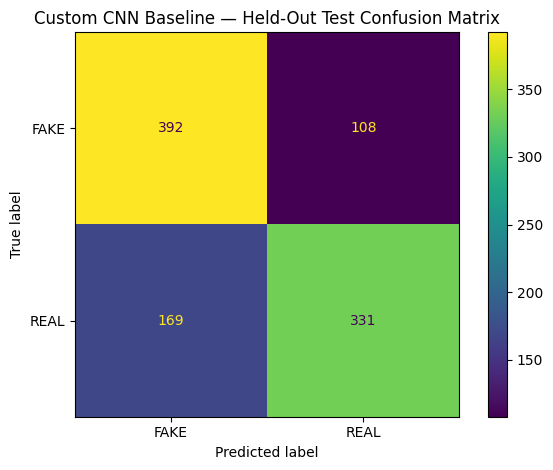

Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/cnn_baseline_confusion_matrix.png
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/cnn_baseline_test_metrics.json


In [15]:
# Cell 15 — Final evaluation on the HELD-OUT TEST set

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

model.eval()

test_metrics, test_labels, test_probs = run_epoch(
    model,
    test_loader,
)

test_preds = (test_probs >= 0.5).astype(int)

print("HELD-OUT TEST RESULTS — CUSTOM CNN BASELINE")
print("-" * 48)

for key, value in test_metrics.items():
    print(f"{key:10s}: {value:.4f}")

print("\nClassification report (FAKE is the positive class):")

print(
    classification_report(
        test_labels,
        test_preds,
        labels=[1, 0],
        target_names=["FAKE", "REAL"],
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(
    test_labels,
    test_preds,
    labels=[1, 0],
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["FAKE", "REAL"],
)

disp.plot(values_format="d")
plt.title("Custom CNN Baseline — Held-Out Test Confusion Matrix")
plt.tight_layout()

cm_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_confusion_matrix.png",
)

plt.savefig(cm_path, dpi=200, bbox_inches="tight")
plt.show()

metrics_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_test_metrics.json",
)

with open(metrics_path, "w") as f:
    json.dump(
        {k: float(v) for k, v in test_metrics.items()},
        f,
        indent=2,
    )

print("Saved:", cm_path)
print("Saved:", metrics_path)


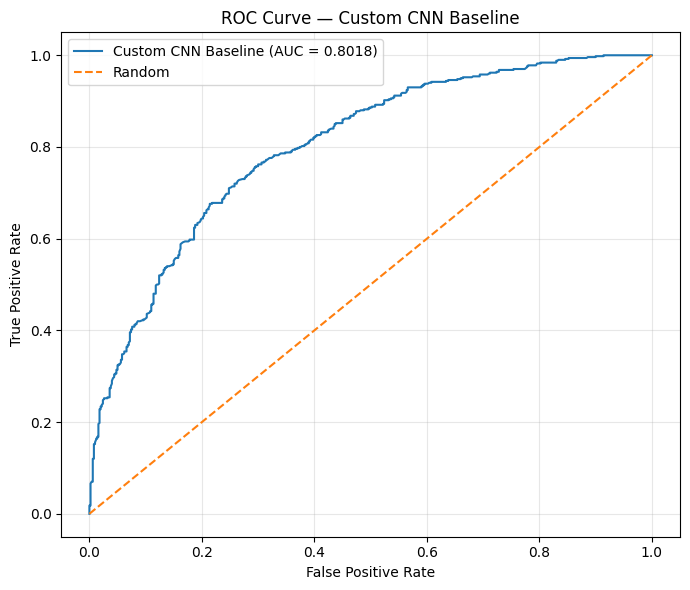

ROC-AUC: 0.8018339999999999
Saved: /content/drive/MyDrive/NNDL_Deepfake_Project/results_cnn_baseline/cnn_baseline_roc_curve.png


In [16]:
# Cell 16 — ROC curve and AUC on the held-out test set

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(test_labels, test_probs)
test_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(
    fpr,
    tpr,
    label=f"Custom CNN Baseline (AUC = {test_auc:.4f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random",
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Custom CNN Baseline")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(
    RESULTS_DIR,
    "cnn_baseline_roc_curve.png",
)

plt.savefig(roc_path, dpi=200, bbox_inches="tight")
plt.show()

print("ROC-AUC:", test_auc)
print("Saved:", roc_path)


In [17]:
# Cell 17 — Save the compact final CNN model for later local inference

final_model_path = os.path.join(
    CHECKPOINT_DIR,
    "cnn_baseline_final.pth",
)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_to_idx": train_dataset.class_to_idx,
        "image_size": IMAGE_SIZE,
        "imagenet_mean": IMAGENET_MEAN,
        "imagenet_std": IMAGENET_STD,
        "architecture": "DeepfakeCNN_custom_baseline",
        "target_convention": "FAKE=1, REAL=0",
        "best_checkpoint_epoch": int(best_ckpt["epoch"]),
        "test_metrics": {
            k: float(v) for k, v in test_metrics.items()
        },
    },
    final_model_path,
)

print("Final CNN baseline model saved to:")
print(final_model_path)


Final CNN baseline model saved to:
/content/drive/MyDrive/NNDL_Deepfake_Project/checkpoints_cnn_baseline/cnn_baseline_final.pth


In [18]:
# Cell 18 — Optional single-image inference using the saved CNN baseline

from PIL import Image
from google.colab import files

uploaded = files.upload()

model.eval()

for filename in uploaded:
    image = Image.open(filename).convert("RGB")
    x = eval_transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.autocast(
            device_type=DEVICE.type,
            dtype=(
                torch.float16
                if DEVICE.type == "cuda"
                else torch.bfloat16
            ),
            enabled=use_amp,
        ):
            logit = model(x)

        fake_probability = torch.sigmoid(logit).item()

    predicted = (
        "FAKE"
        if fake_probability >= 0.5
        else "REAL"
    )

    real_probability = 1.0 - fake_probability
    confidence = max(
        fake_probability,
        real_probability,
    )

    print(f"Image: {filename}")
    print(f"Prediction: {predicted}")
    print(f"Probability of FAKE: {fake_probability:.4f}")
    print(f"Probability of REAL: {real_probability:.4f}")
    print(f"Confidence: {confidence:.4f}")


Saving test 2.jpeg to test 2.jpeg
Image: test 2.jpeg
Prediction: FAKE
Probability of FAKE: 0.9639
Probability of REAL: 0.0361
Confidence: 0.9639
